In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os  


# plot cpu, gpu power pattern for GPGPU apps
def plot_power_CPU_GPU(cpu_filename, gpu_filename, benchmark):
    # Load the CSV files into DataFrames
    cpu_data = pd.read_csv(cpu_filename)
    gpu_data = pd.read_csv(gpu_filename)

    # Plot the data
    plt.figure(figsize=(4, 3))
    plt.plot(cpu_data['Time (s)'], cpu_data['Package Power (W)'], label='RAPL Package Power', color='blue')
    plt.plot(gpu_data['Time (s)'], gpu_data['GPU 0 Power (W)'], label='GPU Power', color='red')
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    plt.title(f'Power Consumption ({benchmark})', pad=40)
    # Position the legend outside the plot
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
    plt.grid(True, axis="y", alpha=0.5)
    
    # Make sure the ./fig directory exists, if not, create it
    os.makedirs('./fig', exist_ok=True)
    # Save the figure
    plt.savefig(f'./fig/power_cpu_gpu_{benchmark}.jpg', bbox_inches='tight')
    plt.show()





# plot the power capping results for GPGPU apps
def plot_power_cap(file_cpu_cap, file_gpu_cap, benchmark,altis):
    def calculate_modified_average(runtimes):
        """Calculate the average runtime after dropping the min and max values."""
        if len(runtimes) > 2:
            return (sum(runtimes) - min(runtimes) - max(runtimes)) / (len(runtimes) - 2)
        return sum(runtimes) / len(runtimes)  # Return average if we can't drop values

    def preprocess_dataframe(file_path):
        """Read and preprocess the data from a CSV file."""
        df = pd.read_csv(file_path)
        # Group by 'CPU Cap (W)' and 'GPU Cap (W)' and aggregate 'Runtime (s)'
        agg_df = df.groupby(['CPU Cap (W)', 'GPU Cap (W)'])['Runtime (s)'].apply(list).reset_index()
        agg_df['Runtime (s)'] = agg_df['Runtime (s)'].apply(calculate_modified_average)
        return agg_df
    
    # Set up subplot environment
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))

    # Process and plot CPU cap data
    df_cpu = preprocess_dataframe(file_cpu_cap)
    # Find base runtime for max CPU Cap
    base_runtime_cpu = df_cpu[df_cpu['CPU Cap (W)'] == df_cpu['CPU Cap (W)'].max()]['Runtime (s)'].iloc[0]
    df_cpu['Performance (%)'] = (base_runtime_cpu / df_cpu['Runtime (s)']) * 100

    # max cpu power cap is 125 for ALTIS, so 250-125 = 125 which is the "decrease start point"
    if altis:
        cap = 125
    else:
        cap = 0
        
    df_cpu['CPU Cap Decrease (W)'] = df_cpu['CPU Cap (W)'].max() + cap - df_cpu['CPU Cap (W)']  # Adjusted for ALTIS benchmark
    axs[0].plot(df_cpu['CPU Cap Decrease (W)'], df_cpu['Performance (%)'], 'o--', linewidth=5, markersize=10)
    axs[0].set_title(f'{benchmark}: fixed max GPU cap', fontsize=20)
    axs[0].set_xlabel('CPU Cap Decrease (W)', fontsize=20)
    axs[0].set_ylabel('Application Performance (%)', fontsize=20)

    # Process and plot GPU cap data
    df_gpu = preprocess_dataframe(file_gpu_cap)
    # Find base runtime for max GPU Cap
    base_runtime_gpu = df_gpu[df_gpu['GPU Cap (W)'] == df_gpu['GPU Cap (W)'].max()]['Runtime (s)'].iloc[0]
    df_gpu['Performance (%)'] = (base_runtime_gpu / df_gpu['Runtime (s)']) * 100
    df_gpu['GPU Cap Decrease (W)'] = df_gpu['GPU Cap (W)'].max() - df_gpu['GPU Cap (W)']
    axs[1].plot(df_gpu['GPU Cap Decrease (W)'], df_gpu['Performance (%)'], 'D--', color='r', linewidth=5, markersize=10)
    axs[1].set_title(f'{benchmark}: fixed max CPU cap', fontsize=20)
    axs[1].set_xlabel('GPU Cap Decrease (W)', fontsize=20)
    axs[1].set_ylabel('Application Performance (%)', fontsize=20)

    for ax in axs:
        ax.tick_params(axis='x', labelsize=20)
        ax.tick_params(axis='y', labelsize=20)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

In [2]:
data_dir = "./altis_power_cap_res/dual_cap/"

# altis_benchmarks_0
busspeeddownload = data_dir + "busspeeddownload_cap_dual.csv"
busspeedreadback = data_dir + "busspeedreadback_cap_dual.csv"
maxflops = data_dir + "maxflops_cap_dual.csv"

# altis_benchmarks_1
bfs = data_dir + "bfs_cap_dual.csv"
gemm = data_dir + "gemm_cap_dual.csv"
gups = data_dir + "gups_cap_dual.csv"
pathfinder = data_dir + "pathfinder_cap_dual.csv"
sort = data_dir + "sort_cap_dual.csv"

# altis_benchmarks_2
cfd = data_dir + "cfd_cap_dual.csv"
cfd_double = data_dir + "cfd_double_cap_dual.csv"
fdtd2d = data_dir + "fdtd2d_cap_dual.csv"
kmeans = data_dir + "kmeans_cap_dual.csv"
lavamd = data_dir + "lavamd_cap_dual.csv"
nw = data_dir + "nw_cap_dual.csv"
particlefilter_float = data_dir + "particlefilter_float_cap_dual.csv"
particlefilter_naive = data_dir + "particlefilter_naive_cap_dual.csv"
raytracing = data_dir + "raytracing_cap_dual.csv"
srad = data_dir + "srad_cap_dual.csv"
where = data_dir + "where_cap_dual.csv"

benchmarks = [busspeeddownload, cfd_double, kmeans, lavamd, particlefilter_naive, raytracing]

In [16]:
def pareto_frontier(Xs, Ys, maxX=True, maxY=False):
    # Including index in the sort to track the original positions
    myList = sorted([(Xs[i], Ys[i], i) for i in range(len(Xs))], reverse=maxX)
    p_front = [myList[0]]
    for pair in myList[1:]:
        if maxY and pair[1] >= p_front[-1][1] or not maxY and pair[1] <= p_front[-1][1]:
            p_front.append(pair)
    p_frontX = [pair[0] for pair in p_front]
    p_frontY = [pair[1] for pair in p_front]
    p_frontIndices = [pair[2] for pair in p_front]  # Indices of points on the Pareto frontier
    return p_frontX, p_frontY, p_frontIndices

def pareto(filename, app,config=0):
    df = pd.read_csv(filename)
    
    # Base case configuration with maximum CPU and GPU caps
    max_cpu_cap = df['CPU Cap (W)'].max()
    max_gpu_cap = df['GPU Cap (W)'].max()
    base_case = df.loc[(df['CPU Cap (W)'] == max_cpu_cap) & (df['GPU Cap (W)'] == max_gpu_cap)]
    base_runtime = base_case['Runtime (s)'].iloc[0]
    base_energy = (base_case['CPU_E (J)'] + base_case['GPU_E (J)']).iloc[0]

    # Calculations for speedup and normalized total energy consumption
    df['Speedup'] = base_runtime / df['Runtime (s)']
    df['Total Energy (J)'] = df['CPU_E (J)'] + df['GPU_E (J)']
    df['Normalized Energy'] = df['Total Energy (J)'] / base_energy

    # Filtering
    df_filtered = df[(df['CPU_E (J)'] > 0) & (df['GPU_E (J)'] > 0)]
    
    # Lists for plotting
    speedups = df_filtered['Speedup'].tolist()
    normalized_energies = df_filtered['Normalized Energy'].tolist()
    
    # Pareto frontier
    p_frontX, p_frontY, p_frontIndices = pareto_frontier(speedups, normalized_energies, maxX=True, maxY=False)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(speedups, normalized_energies, marker="+", color='#280274')
    plt.scatter([1], [1], color='red', marker='o', s=100)  # Base case marker
    plt.plot(p_frontX, p_frontY, color='#FF9800', linewidth=2)
    
    plt.xlabel('Speedup', fontsize=18)
    plt.ylabel('Normalized Energy', fontsize=18)
    plt.title(app, fontsize=20)
    plt.grid(True)
    
    if config:
            # Print configurations on the Pareto frontier with 2 decimal places
            print("Configurations on the Pareto frontier:")
            for index in p_frontIndices:
                row = df_filtered.iloc[index]
                cpu_cap = row['CPU Cap (W)']
                gpu_cap = row['GPU Cap (W)']
                speedup = round(row['Speedup'], 2)
                normalized_energy = round(row['Normalized Energy'], 2)
                print(f"CPU Cap (W): {cpu_cap}, GPU Cap (W): {gpu_cap}, Speedup: {speedup}, Normalized Energy: {normalized_energy}")
            
    plt.show()

Configurations on the Pareto frontier:
CPU Cap (W): 105.0, GPU Cap (W): 260.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 85.0, GPU Cap (W): 260.0, Speedup: 0.98, Normalized Energy: 0.97
CPU Cap (W): 80.0, GPU Cap (W): 260.0, Speedup: 0.98, Normalized Energy: 0.95
CPU Cap (W): 75.0, GPU Cap (W): 260.0, Speedup: 0.97, Normalized Energy: 0.93
CPU Cap (W): 70.0, GPU Cap (W): 260.0, Speedup: 0.97, Normalized Energy: 0.93
CPU Cap (W): 75.0, GPU Cap (W): 160.0, Speedup: 0.96, Normalized Energy: 0.92
CPU Cap (W): 65.0, GPU Cap (W): 260.0, Speedup: 0.96, Normalized Energy: 0.92
CPU Cap (W): 70.0, GPU Cap (W): 160.0, Speedup: 0.95, Normalized Energy: 0.91
CPU Cap (W): 65.0, GPU Cap (W): 160.0, Speedup: 0.94, Normalized Energy: 0.9
CPU Cap (W): 80.0, GPU Cap (W): 140.0, Speedup: 0.92, Normalized Energy: 0.9
CPU Cap (W): 75.0, GPU Cap (W): 140.0, Speedup: 0.91, Normalized Energy: 0.88
CPU Cap (W): 70.0, GPU Cap (W): 140.0, Speedup: 0.91, Normalized Energy: 0.86
CPU Cap (W): 65.0, GPU Cap (

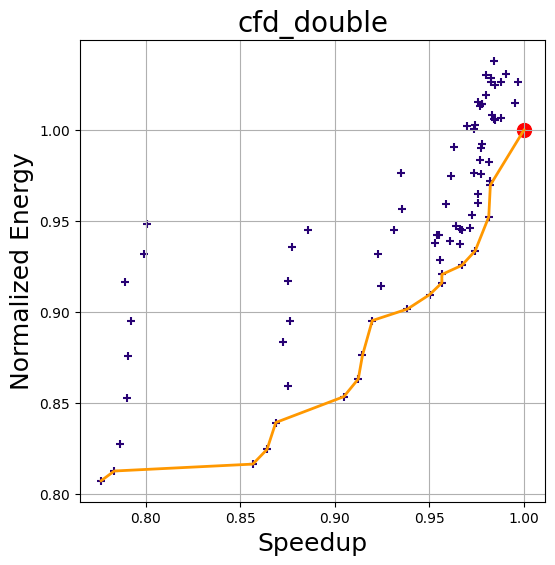

In [17]:
pareto(cfd_double,"cfd_double",1)

Configurations on the Pareto frontier:
CPU Cap (W): 105.0, GPU Cap (W): 260.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 105.0, GPU Cap (W): 240.0, Speedup: 0.98, Normalized Energy: 0.97
CPU Cap (W): 105.0, GPU Cap (W): 200.0, Speedup: 0.98, Normalized Energy: 0.97
CPU Cap (W): 100.0, GPU Cap (W): 120.0, Speedup: 0.97, Normalized Energy: 0.95


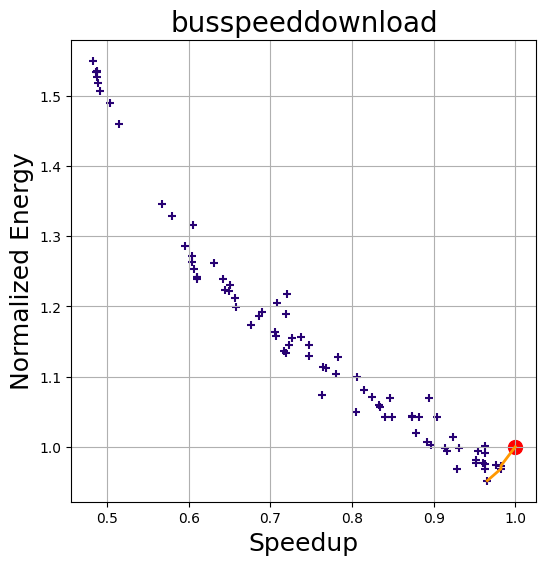

Configurations on the Pareto frontier:
CPU Cap (W): 105.0, GPU Cap (W): 260.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 85.0, GPU Cap (W): 260.0, Speedup: 0.98, Normalized Energy: 0.97
CPU Cap (W): 80.0, GPU Cap (W): 260.0, Speedup: 0.98, Normalized Energy: 0.95
CPU Cap (W): 75.0, GPU Cap (W): 260.0, Speedup: 0.97, Normalized Energy: 0.93
CPU Cap (W): 70.0, GPU Cap (W): 260.0, Speedup: 0.97, Normalized Energy: 0.93
CPU Cap (W): 75.0, GPU Cap (W): 160.0, Speedup: 0.96, Normalized Energy: 0.92
CPU Cap (W): 65.0, GPU Cap (W): 260.0, Speedup: 0.96, Normalized Energy: 0.92
CPU Cap (W): 70.0, GPU Cap (W): 160.0, Speedup: 0.95, Normalized Energy: 0.91
CPU Cap (W): 65.0, GPU Cap (W): 160.0, Speedup: 0.94, Normalized Energy: 0.9
CPU Cap (W): 80.0, GPU Cap (W): 140.0, Speedup: 0.92, Normalized Energy: 0.9
CPU Cap (W): 75.0, GPU Cap (W): 140.0, Speedup: 0.91, Normalized Energy: 0.88
CPU Cap (W): 70.0, GPU Cap (W): 140.0, Speedup: 0.91, Normalized Energy: 0.86
CPU Cap (W): 65.0, GPU Cap (

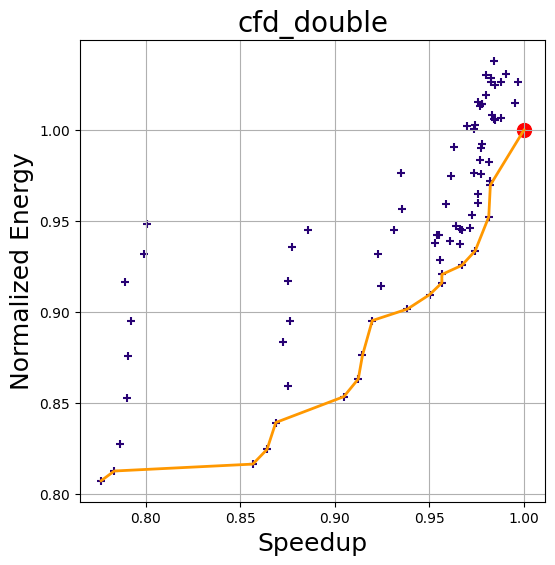

Configurations on the Pareto frontier:
CPU Cap (W): 105.0, GPU Cap (W): 240.0, Speedup: 1.0, Normalized Energy: 1.01
CPU Cap (W): 100.0, GPU Cap (W): 240.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 105.0, GPU Cap (W): 260.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 95.0, GPU Cap (W): 260.0, Speedup: 1.0, Normalized Energy: 0.97
CPU Cap (W): 100.0, GPU Cap (W): 200.0, Speedup: 0.99, Normalized Energy: 0.95
CPU Cap (W): 95.0, GPU Cap (W): 200.0, Speedup: 0.99, Normalized Energy: 0.94
CPU Cap (W): 105.0, GPU Cap (W): 180.0, Speedup: 0.98, Normalized Energy: 0.93
CPU Cap (W): 100.0, GPU Cap (W): 180.0, Speedup: 0.96, Normalized Energy: 0.93
CPU Cap (W): 95.0, GPU Cap (W): 180.0, Speedup: 0.96, Normalized Energy: 0.92
CPU Cap (W): 105.0, GPU Cap (W): 160.0, Speedup: 0.96, Normalized Energy: 0.9
CPU Cap (W): 85.0, GPU Cap (W): 180.0, Speedup: 0.95, Normalized Energy: 0.89
CPU Cap (W): 95.0, GPU Cap (W): 160.0, Speedup: 0.93, Normalized Energy: 0.88
CPU Cap (W): 90.0, GPU Ca

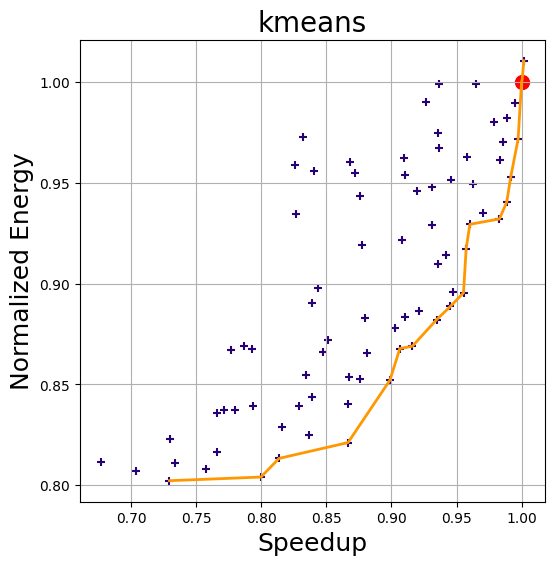

Configurations on the Pareto frontier:
CPU Cap (W): 105.0, GPU Cap (W): 220.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 95.0, GPU Cap (W): 160.0, Speedup: 0.99, Normalized Energy: 0.98
CPU Cap (W): 95.0, GPU Cap (W): 220.0, Speedup: 0.98, Normalized Energy: 0.98
CPU Cap (W): 95.0, GPU Cap (W): 140.0, Speedup: 0.97, Normalized Energy: 0.96
CPU Cap (W): 105.0, GPU Cap (W): 120.0, Speedup: 0.96, Normalized Energy: 0.96
CPU Cap (W): 95.0, GPU Cap (W): 120.0, Speedup: 0.95, Normalized Energy: 0.93
CPU Cap (W): 80.0, GPU Cap (W): 120.0, Speedup: 0.9, Normalized Energy: 0.9
CPU Cap (W): 75.0, GPU Cap (W): 120.0, Speedup: 0.86, Normalized Energy: 0.9
CPU Cap (W): 80.0, GPU Cap (W): 100.0, Speedup: 0.84, Normalized Energy: 0.88
CPU Cap (W): 75.0, GPU Cap (W): 100.0, Speedup: 0.82, Normalized Energy: 0.87


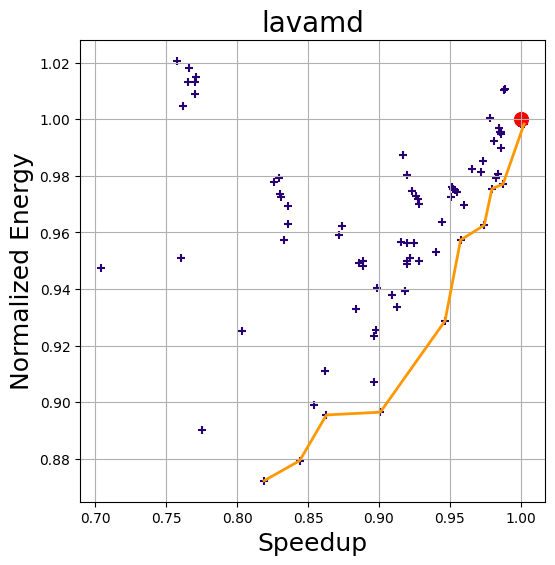

Configurations on the Pareto frontier:
CPU Cap (W): 105.0, GPU Cap (W): 240.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 105.0, GPU Cap (W): 180.0, Speedup: 1.0, Normalized Energy: 1.0
CPU Cap (W): 105.0, GPU Cap (W): 160.0, Speedup: 1.0, Normalized Energy: 0.99
CPU Cap (W): 105.0, GPU Cap (W): 140.0, Speedup: 0.99, Normalized Energy: 0.99
CPU Cap (W): 95.0, GPU Cap (W): 160.0, Speedup: 0.98, Normalized Energy: 0.97
CPU Cap (W): 95.0, GPU Cap (W): 140.0, Speedup: 0.97, Normalized Energy: 0.96
CPU Cap (W): 95.0, GPU Cap (W): 120.0, Speedup: 0.96, Normalized Energy: 0.96
CPU Cap (W): 95.0, GPU Cap (W): 100.0, Speedup: 0.95, Normalized Energy: 0.95


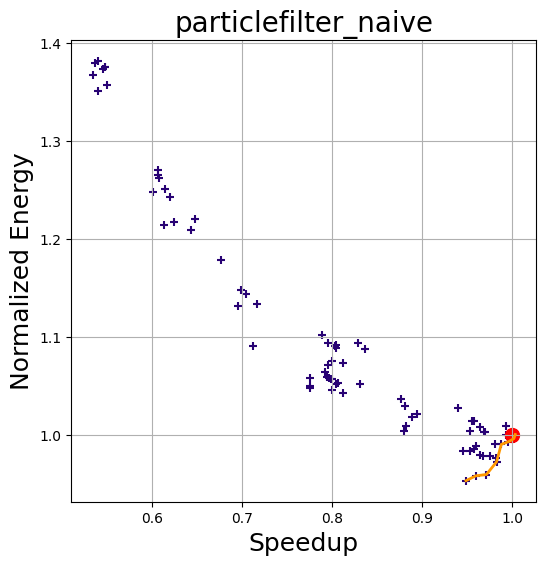

Configurations on the Pareto frontier:
CPU Cap (W): 90.0, GPU Cap (W): 220.0, Speedup: 1.0, Normalized Energy: 0.86
CPU Cap (W): 105.0, GPU Cap (W): 200.0, Speedup: 1.0, Normalized Energy: 0.85
CPU Cap (W): 95.0, GPU Cap (W): 200.0, Speedup: 1.0, Normalized Energy: 0.82
CPU Cap (W): 90.0, GPU Cap (W): 200.0, Speedup: 0.99, Normalized Energy: 0.81
CPU Cap (W): 95.0, GPU Cap (W): 180.0, Speedup: 0.99, Normalized Energy: 0.77
CPU Cap (W): 70.0, GPU Cap (W): 200.0, Speedup: 0.98, Normalized Energy: 0.76
CPU Cap (W): 65.0, GPU Cap (W): 200.0, Speedup: 0.98, Normalized Energy: 0.76
CPU Cap (W): 85.0, GPU Cap (W): 180.0, Speedup: 0.98, Normalized Energy: 0.75
CPU Cap (W): 80.0, GPU Cap (W): 180.0, Speedup: 0.98, Normalized Energy: 0.74
CPU Cap (W): 75.0, GPU Cap (W): 180.0, Speedup: 0.98, Normalized Energy: 0.72
CPU Cap (W): 85.0, GPU Cap (W): 160.0, Speedup: 0.98, Normalized Energy: 0.7
CPU Cap (W): 65.0, GPU Cap (W): 180.0, Speedup: 0.98, Normalized Energy: 0.7
CPU Cap (W): 80.0, GPU Cap (W

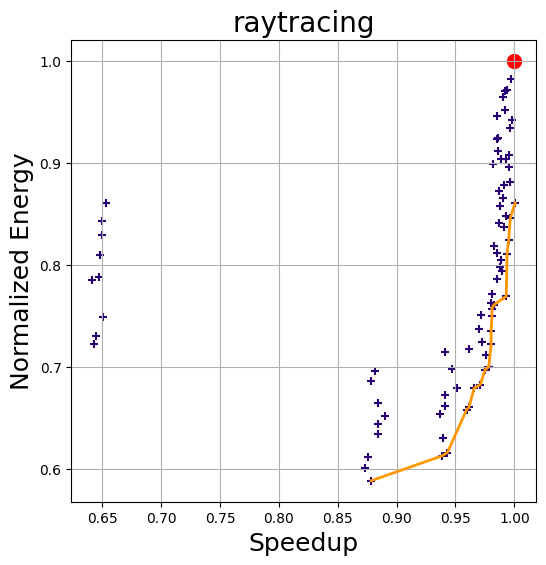

In [18]:
for benchmark in benchmarks:
    # Extract the benchmark name from the file path
    benchmark_name = os.path.basename(benchmark).split("_cap_dual.csv")[0]
    pareto(benchmark, benchmark_name,1)